# CivicRoute AI Course Assessment Starter Notebook

**Student name:**  Tayyab Sharjil Akram

**Student number:** 116062

**GitHub repository:**  https://github.com/sherjaan707-sudo/civic_route_ai.git

This notebook supports the **revised structured-data assessment only**.

Use short, clearly labelled code sections. The assessment is not about producing a long notebook. Your aim is to create enough technical evidence to explain your decisions and results in the recorded video.

The notebook mainly supports:

- **Step 2:** Inspect and prepare the data with Pandas and NumPy.
- **Step 3:** Build one small TensorFlow/Keras model.
- **Step 4:** Record evidence for interpretation and explainability discussion.

GitHub workflow evidence, graph/GNN discussion and the final recommendation are demonstrated or discussed in the video rather than implemented here.


## Step 2: Inspect and prepare the data with Pandas and NumPy

### 2.1 Load and inspect the supplied dataset

Show the dataset shape, field names, data types, target-category counts and missing-value summary.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)


# Recommended repository structure:
# project/
# ├── civicroute_assessment.ipynb
# └── data/
#     └── civic_requests_prepared.csv

DATA_PATH = Path("data/civic_requests_prepared.csv")

# If you keep the CSV beside the notebook instead, this fallback will find it.
if not DATA_PATH.exists():
    DATA_PATH = Path("civic_requests_prepared.csv")

df = pd.read_csv(DATA_PATH)


In [2]:
print("Shape:", df.shape)
print("\nField names:")
print(df.columns.tolist())
print("\nData types:")
df.info()


Shape: (600, 13)

Field names:
['request_id', 'created_hour', 'neighbourhood', 'channel', 'urgency_level', 'recent_rain_flag', 'night_report_flag', 'repeat_report_count', 'image_quality_score', 'nearby_asset_age_years', 'description_word_count', 'previous_resolution_days', 'category_label']

Data types:
<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   request_id                600 non-null    str    
 1   created_hour              600 non-null    int64  
 2   neighbourhood             600 non-null    str    
 3   channel                   596 non-null    str    
 4   urgency_level             600 non-null    str    
 5   recent_rain_flag          600 non-null    str    
 6   night_report_flag         600 non-null    str    
 7   repeat_report_count       600 non-null    int64  
 8   image_quality_score       590 non-null    floa

In [3]:
print(df["category_label"].value_counts())


category_label
pothole               150
water_leak            150
broken_streetlight    150
illegal_dumping       150
Name: count, dtype: int64


In [4]:
missing = df.isna().sum()
print(missing[missing > 0])


channel                      4
image_quality_score         10
previous_resolution_days     9
dtype: int64


In [5]:
df.head()


,request_id,created_hour,neighbourhood,channel,urgency_level,recent_rain_flag,night_report_flag,repeat_report_count,image_quality_score,nearby_asset_age_years,description_word_count,previous_resolution_days,category_label
0,REQ-10001,18,North End,call_centre,medium,yes,yes,3,0.756,21.9,13,11.2,pothole
1,REQ-10002,8,Hillside,mobile_app,medium,yes,no,3,0.555,20.2,16,8.3,pothole
2,REQ-10003,20,Eastview,mobile_app,medium,no,yes,2,0.882,30.7,18,6.3,pothole
3,REQ-10004,11,South Park,mobile_app,medium,no,no,1,0.645,17.4,19,10.8,pothole
4,REQ-10005,20,Hillside,call_centre,medium,yes,yes,2,0.640,32.0,12,8.9,pothole


In [6]:
df.describe().round(2)


,created_hour,repeat_report_count,image_quality_score,nearby_asset_age_years,description_word_count,previous_resolution_days
count,600.00,600.00,590.00,600.00,600.00,591.00
mean,13.73,3.19,0.69,22.10,16.08,8.61
std,5.95,2.10,0.15,10.80,6.14,4.33
min,0.00,0.00,0.15,0.00,4.00,1.00
25%,9.00,2.00,0.59,14.70,11.75,5.55
50%,14.00,3.00,0.69,21.60,15.00,8.00
75%,19.00,4.00,0.80,28.42,20.00,11.20
max,23.00,12.00,1.00,54.70,36.00,21.90


In [7]:
# Average of a numerical feature per category
print(df.groupby("category_label")["repeat_report_count"].mean().round(2))

# Share of rain / no rain within each category
print(pd.crosstab(df["category_label"], df["recent_rain_flag"], normalize="index").round(2))


category_label
broken_streetlight    1.96
illegal_dumping       4.85
pothole               2.47
water_leak            3.47
Name: repeat_report_count, dtype: float64
recent_rain_flag      no   yes
category_label                
broken_streetlight  0.70  0.30
illegal_dumping     0.85  0.15
pothole             0.37  0.63
water_leak          0.29  0.71


#### Comments 2.1 – Dataset inspection

- The dataset has 600 rows × 13 columns.
- It has 3 integer fields, 3 decimal fields and 7 text fields.
- `category_label` is the target and is fully balanced across four classes (150 each).

Missing values are minimal (`channel`: 4, `image_quality_score`: 10, `previous_resolution_days`: 9), all below 2%, so I will impute rather than remove rows.

### 2.2 Select the fields and identify the target

Choose the fields you believe are relevant to the prototype. Exclude identifiers and avoid using any field simply because it is available. State the target column clearly.


In [8]:
TARGET = "category_label" # distinct labels:
                          # 1.broken_streetlight
                          # 2. illegal_dumping      
                          # 3. pothole
                          # 4.water_leak

# 1. Select the input fields you intend to use.
selected_features = [
    "created_hour", # provide timings for request initiation ie more broken lights in the night
    "channel",      
    "urgency_level",
    "recent_rain_flag",
    "repeat_report_count",
    "image_quality_score",
    "nearby_asset_age_years",
    "description_word_count",
]

# 2. Exclude request_id from the model inputs.
excluded_fields = [
    "request_id",                # identifier, dont help to predict
    "night_report_flag",         # created hour is sufficient, dont need it
    "neighbourhood",             # fairness might be affected adding bias
    "previous_resolution_days",  # not to predict neither applicable when new data used
]

# 3. Create a working DataFrame containing the selected inputs and TARGET.
work_df = df[selected_features + [TARGET]].copy() # .copy = independent separate table

# 4. Display the selected field names.
print("Target:", TARGET)
print("Selected input fields:", selected_features)
print("Excluded fields:", excluded_fields)
print("Working data shape:", work_df.shape)


Target: category_label
Selected input fields: ['created_hour', 'channel', 'urgency_level', 'recent_rain_flag', 'repeat_report_count', 'image_quality_score', 'nearby_asset_age_years', 'description_word_count']
Excluded fields: ['request_id', 'night_report_flag', 'neighbourhood', 'previous_resolution_days']
Working data shape: (600, 9)


#### Comments 2.2 – Field selection

**Target column:** `category_label`

1. `broken_streetlight`
2. `illegal_dumping`
3. `pothole`
4. `water_leak`

**Fields kept**

I kept the fields that are available when a new request comes in and that will help us predict the four categories apart.

- `created_hour`: Problems like broken streetlights are noticed more in the evening and at night, i.e. after 18:00.
- `channel`: People report different problems in different ways, while some neighbourhoods might not have access to certain apps.
- `urgency_level`: Some problems like water leaks are usually more urgent.
- `recent_rain_flag`: Rain can cause water leaks and potholes. 71% of `water_leak` requests and 63% of `pothole` requests came after recent rain.
- `repeat_report_count`: Visible problems like dumping get reported by more people. Illegal dumping averages 4.85 repeat reports, compared with 3.19 overall.
- `image_quality_score`: Some problems are easier to photograph than others.
- `nearby_asset_age_years`: Older pipes and roads are more likely to break.
- `description_word_count`: Some problems take more words to describe, like illegal dumping.

**Fields removed**

- `request_id`: Just an identifier. No value being added.
- `night_report_flag`: Comes from `created_hour`, so it repeats the same information.
- `neighbourhood`: Could add bias, because some areas report more than others.
- `previous_resolution_days`: Would not be part of the data for a new request in the future.

A multi-class classification will be used.

### 2.3 Handle the small number of missing values

Use one sensible course-level method for the supplied missing values. Keep the code short and note why the method is appropriate so that you can explain the choice in your video.


In [9]:

# Inspect the missing values in your selected fields.
missing_before = work_df.isna().sum()
print("Missing values in selected fields:")
print(missing_before[missing_before > 0])


# Handle them using an appropriate method:

# - image quality is numerical so median was used to better represent outliers
image_quality_median = work_df["image_quality_score"].median()
work_df["image_quality_score"] = work_df["image_quality_score"].fillna(image_quality_median)


# - categorical strategy for channel.
channel_mode = work_df["channel"].mode()[0]
work_df["channel"] = work_df["channel"].fillna(channel_mode)

#
# Show a short before/after missing-value check.
print("Missing values after:")
print(work_df.isna().sum())


Missing values in selected fields:
channel                 4
image_quality_score    10
dtype: int64
Missing values after:
created_hour              0
channel                   0
urgency_level             0
recent_rain_flag          0
repeat_report_count       0
image_quality_score       0
nearby_asset_age_years    0
description_word_count    0
category_label            0
dtype: int64


#### Comments 2.3 – Handling missing values

Only a few values were missing, so I filled them instead of dropping rows.

- I filled the 4 missing `channel` values with the most common value, `mobile_app`.
- I filled the 10 missing `image_quality_score` values with the median, because a few extreme scores won’t skew it.
- I left `previous_resolution_days` as it was because I’m not using it in the model.

### 2.4 Apply simple transformation or encoding

Prepare categorical data so that a neural network can use it. Use a short NumPy operation where it adds value, such as a vectorised numerical transformation or inspection of an array.


In [10]:

# 1. Encode the selected categorical input fields.
# yes/no  to 1-0
work_df["recent_rain_flag"] = np.where(work_df["recent_rain_flag"] == "yes", 1, 0)
# cat. to numerical (0,1,2) order
urgency_map = {"low": 0, "medium": 1, "high": 2}
work_df["urgency_level"] = work_df["urgency_level"].map(urgency_map)
# no order so hot encoding 0/1
work_df = pd.get_dummies(work_df, columns=["channel"], dtype=int)

# 2. Encode the target labels into numeric class values.
class_names = sorted(work_df[TARGET].unique())
class_to_index = {name: i for i, name in enumerate(class_names)}
y = work_df[TARGET].map(class_to_index).to_numpy()

# 3. Use one short NumPy array/vectorised operation where appropriate.
numeric_cols = [
    "created_hour",
    "repeat_report_count",
    "image_quality_score",
    "nearby_asset_age_years",
    "description_word_count",
]
numeric_values = work_df[numeric_cols].to_numpy(dtype=float)
means = numeric_values.mean(axis=0)
stds = numeric_values.std(axis=0)
work_df[numeric_cols] = (numeric_values - means) / stds

# 4. Create the final feature matrix X and target vector y.
X = work_df.drop(columns=[TARGET]).to_numpy(dtype="float32")

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Class mapping:", class_to_index)

X shape: (600, 11)
y shape: (600,)
Class mapping: {'broken_streetlight': 0, 'illegal_dumping': 1, 'pothole': 2, 'water_leak': 3}


### 2.5 Confirm the model-ready data

Show the final model-ready shape or a small sample of the prepared data. Note what changed from the original dataset and why.


In [11]:

# Column names, so the sample is easy to read
feature_names = work_df.drop(columns=[TARGET]).columns.tolist()

# - X shape
print("X shape:", X.shape)

# - y shape
print("y shape:", y.shape)

# - a small sample of prepared inputs
print("\nFirst 5 rows of prepared inputs:")
print(pd.DataFrame(X[:5], columns=feature_names).round(2))
print("First 5 target values:", y[:5])

# - the target/class mapping
print("\nClass mapping:", class_to_index)
print("Records per class:", np.bincount(y))


X shape: (600, 11)
y shape: (600,)

First 5 rows of prepared inputs:
   created_hour  urgency_level  recent_rain_flag  repeat_report_count  \
0          0.72            1.0               1.0                -0.09   
1         -0.96            1.0               1.0                -0.09   
2          1.06            1.0               0.0                -0.57   
3         -0.46            1.0               0.0                -1.04   
4          1.06            1.0               1.0                -0.57   

   image_quality_score  nearby_asset_age_years  description_word_count  \
0                 0.45                   -0.02                   -0.50   
1                -0.87                   -0.18                   -0.01   
2                 1.27                    0.80                    0.31   
3                -0.28                   -0.44                    0.48   
4                -0.31                    0.92                   -0.66   

   channel_call_centre  channel_mobile_app  cha

#### Comments 2.5 – Model-ready data

I started with 600 rows and 13 columns. I removed four columns:

- `request_id`
- `night_report_flag`
- `neighbourhood`
- `previous_resolution_days`

That left 9 columns. I moved the target into `y`, which left 8 input columns. Then I one-hot encoded `channel` into four separate columns, so the final data has 600 rows and 11 input columns. If I gave each channel a number like 0, 1, 2 or 3, the model would think some channels are bigger than others. That is wrong, because channels are just different ways to contact the council.

**What the sample shows**

- The number columns are scaled. That’s why they look like 0.72 or -0.09 instead of the original values. This stops a feature with big numbers from mattering more than a feature with small numbers.
- Urgency is 0, 1 or 2 (low, medium, high). I kept it as one column because the levels have a natural order.
- Rain is 1 for yes and 0 for no.
- Channel has one column for each channel. A request has a 1 in the column for its channel and 0 in the others.

**Target**

The target has 4 labels, but I kept it as one column with the numbers 0–3: `broken_streetlight` = 0, `illegal_dumping` = 1, `pothole` = 2, `water_leak` = 3. The model’s output layer has 4 neurons, one per category, so it can compare its prediction directly with this single number. Each category has 150 records, showing the data is balanced and not skewed.

The first five targets are all `pothole` because the file is sorted by category. The data will be shuffled when I split it, so each set gets a fair mix of all four categories.

## Step 3: Build one small TensorFlow/Keras model

The model should be deliberately modest. One or two hidden Dense layers are sufficient. No extensive tuning or competing models are required.


### 3.1 Create reproducible training, validation and test data


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(RANDOM_SEED)

# Split 1: 70% training, 30% kept aside
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=y
)

# Split 2: the 30% is divided equally into validation and test 15% each
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=RANDOM_SEED,
    stratify=y_temp
)

# Show the size of each split
print("Training:  ", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:      ", X_test.shape, y_test.shape)
print("Records per class (train):", np.bincount(y_train))

Training:   (420, 11) (420,)
Validation: (90, 11) (90,)
Test:       (90, 11) (90,)
Records per class (train): [105 105 105 105]


### 3.2 Define a small Sequential classification model


In [13]:
# ---------------------------------------------------------
# Model size settings (taken from the data)
# ---------------------------------------------------------
num_features = X_train.shape[1]  # 11 inputs
num_classes = len(class_to_index)  # 4 categories

# ---------------------------------------------------------
# 1. Define a small keras.Sequential model using Dense layers
# 2. One or two hidden layers are sufficient
# 3. Output layer matches the number of target classes
# ---------------------------------------------------------
model = keras.Sequential([
    keras.Input(shape=(num_features,)),  # input: 11 features
    layers.Dense(16, activation="relu"),  # hidden layer 1
    layers.Dense(8, activation="relu"),  # hidden layer 2
    layers.Dense(num_classes, activation="softmax"),  # output: 4 classes
])

# ---------------------------------------------------------
# Model summary
# ---------------------------------------------------------
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 364 (1.42 KB)

 Trainable params: 364 (1.42 KB)

 Non-trainable params: 0 (0.00 B)

### 3.3 Compile and train the model


In [16]:
# 1. Choose a suitable loss function.
# My labels are integers (0-3), so I use sparse categorical crossentropy.
loss_function = "sparse_categorical_crossentropy"

# 2. Choose a suitable optimiser.
# Adam is an adaptive optimiser, so it adjusts the step size during training.
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

# 3. Compile the model.
model.compile(
    optimizer=optimizer,
    loss=loss_function,
    metrics=["accuracy"]
)

# 4. Train for a modest number of epochs and include validation data.
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val)
)

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.2452 - loss: 1.4205 - val_accuracy: 0.3000 - val_loss: 1.4220
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2714 - loss: 1.3716 - val_accuracy: 0.3111 - val_loss: 1.3853
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3095 - loss: 1.3310 - val_accuracy: 0.3000 - val_loss: 1.3536
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3286 - loss: 1.2939 - val_accuracy: 0.3333 - val_loss: 1.3240
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3738 - loss: 1.2589 - val_accuracy: 0.3333 - val_loss: 1.2952
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4143 - loss: 1.2249 - val_accuracy: 0.3778 - val_loss: 1.2664
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4476 - loss: 1.1902 - val_accuracy: 0.4333 - val_loss: 1.2390
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5238 - loss: 1.1527 - val_accuracy: 0.4667 - val_loss

### 3.4 Show the training and validation behaviour


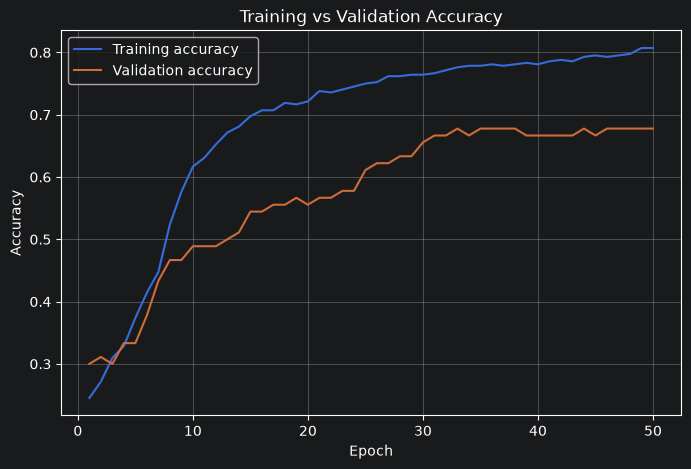

Final training accuracy:   0.8071
Final validation accuracy: 0.6778
Gap (train - validation):  0.1294
Best validation accuracy:  0.6778 at epoch 33


In [18]:
# Plot the most useful training evidence.
# At minimum, show training and validation accuracy or loss.
# Keep the plot clear enough to explain in the video.

train_acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

epochs = range(1, len(train_acc) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc, label="Training accuracy")
plt.plot(epochs, val_acc, label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Final values to support the plot
print(f"Final training accuracy:   {train_acc[-1]:.4f}")
print(f"Final validation accuracy: {val_acc[-1]:.4f}")
print(f"Gap (train - validation):  {train_acc[-1] - val_acc[-1]:.4f}")
print(f"Best validation accuracy:  {max(val_acc):.4f} at epoch {val_acc.index(max(val_acc)) + 1}")

### 3.5 Evaluate the prototype

Report overall test accuracy and produce a confusion matrix. These are the main outputs you will use when explaining one strength, one weakness or risky error, and what should happen next.


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7111 - loss: 0.7687
Test Accuracy: 0.7111
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
[[14  0  6  3]
 [ 0 20  2  0]
 [ 2  2 15  4]
 [ 0  3  4 15]]


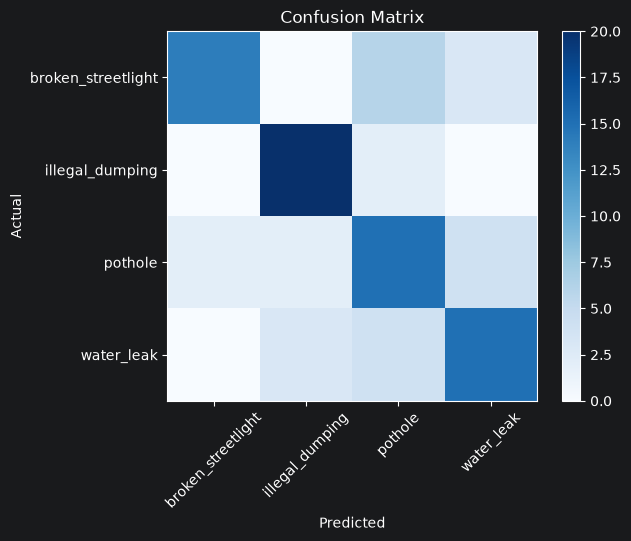

In [20]:
# 1. Evaluate the model on the test data.
loss, accuracy = model.evaluate(X_test, y_test)

# 2. Print the overall test accuracy.
print(f"Test Accuracy: {accuracy:.4f}")

# 3. Generate test predictions.
# The highest probability indicates the model's prediction
y_prob = model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)

# 4. Produce and display a confusion matrix.
cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)
plt.colorbar()
plt.show()

## Step 4: Interpretation and explainability notes

No XAI library needs to be implemented in this notebook. Use the evidence above to prepare for the video discussion.

Record brief notes for yourself:

1. What do the training and validation results suggest about the model?
2. What does the test result and confusion matrix reveal?
3. What is one useful strength and one important weakness or risky error?
4. Compare one **model-agnostic** explanation method and one **model-specific** explanation method from the course.
5. Which explanation approach is more appropriate for this tabular prototype, and why?
6. What additional evidence or improvement would make you more confident in CivicRoute AI?


## Step 5 reminder: Graph-based modelling and GNNs

**No graph or GNN implementation is required.**

Prepare to explain in the video:

- useful node types;
- useful relationships or edges;
- one question a graph representation could help investigate;
- where a GNN could add value if CivicRoute AI became more relationship-driven; and
- whether a GNN is justified for the current prototype or should be considered later.


## Step 6 reminder: GitHub evidence

Keep this notebook and the selected supporting evidence in your GitHub repository.

Your video must demonstrate the GitHub workflow required by the assessment brief, including:

- a meaningful local change followed by add, commit and push;
- a remote change followed by pull;
- a branch-and-merge workflow;
- repository history; and
- how the README and file structure support reproducibility.

Commit meaningful milestones as you work rather than making one large final commit.


## Final recommendation notes

Before recording the final part of your video, return to the central question:

**Based on the evidence from your small prototype, what does CivicRoute AI appear capable of, what should be treated with caution, and what should the council do next?**

Base your recommendation on the evidence produced in this notebook rather than on accuracy alone.
